In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
from torch_snippets import Report
import numpy as np
from torch.utils.data import Dataset, DataLoader
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
np.random.seed(42)


In [2]:
piece_lookup = {
    0 : "K",
    1 : "Q",
    2 : "R",
    3 : "B",
    4 : "N",
    5 : "P",
    6 : "k",
    7 : "q",
    8 : "r",
    9 : "b",
    10 : "n",
    11 : "p",
    6 : "1",
}

value_lookup = {
    "K" : 0,
    "Q" : 1,
    "R" : 2,
    "B" : 3,
    "N" : 4,
    "P" : 5,
    "k" : 6,
    "q" : 7,
    "r" : 8,
    "b" : 9,
    "n" : 10,
    "p" : 11,
}

def y_to_fens(results):
    fens = []

    for i in range(results.shape[0]):
        fen = ''
        empty = 0

        for j in range(64):
            if np.argmax(results[i, j, :]) == 12:
                empty += 1
            else:
                if empty != 0:
                    fen += str(empty)
                    empty = 0
                piece_idx = np.argmax(results[i, j, :])
                fen += piece_lookup[piece_idx]

            if (j+1) % 8 == 0 and j < 63:
                if empty != 0:
                    fen += str(empty)
                    empty = 0
                fen += '/'

        fens.append(fen)
    
    return fens

def fens_to_y(fens):
    results = np.zeros((len(fens), 64, 13))

    for i, fen in enumerate(fens):

        fen = fen.split()[0]
        
        rows = fen.split('/')
        col = 0
        for j, row in enumerate(rows):  
            for char in row:
                if char.isdigit():
                    aux = col + int(char)
                    results[i, col:aux, 12] = 1
                    col = aux
                else:
                    piece_idx = value_lookup[char]
                    results[i, col, piece_idx] = 1
                    col += 1

    return results

In [3]:
class PieceImageClassifier(nn.Module):
    def __init__(self):
        super(PieceImageClassifier, self).__init__()

        self.model = models.mobilenet_v2(weights="MobileNet_V2_Weights.DEFAULT")

        self.model.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), 
            nn.Flatten(),
            nn.Linear(1280, 512),
            nn.ReLU(),
            nn.Linear(512, 12)
        )

    def forward(self, x):
        aux = self.model.features(x)
        outputs = self.model.classifier(aux)
        return outputs

class GamesDataset(Dataset):
    def __init__(self, images, fen):
        self.x = images
        self.y = torch.from_numpy(fen).type(torch.FloatTensor)
        self.n_samples = images.shape[0]
    
    def __getitem__(self, index):
        return (self.x[index], self.y[index])

    def __len__(self):
        return self.n_samples

In [ ]:
import torch
import numpy as np

# Load the data
imagens_array = torch.load("../Datasets/Images/processed_images/imagens_casa_tensor_real.pt")
fens = np.load("../Datasets/Images/processed_images/pecas_casa_tensor_real.npy")

# Check dimensions
print("Tensor dimensions:", imagens_array.size())  # Tensor dimensions
print("Label dimensions:", fens.shape)            # Label dimensions

# Ensure the dataset sizes match
assert imagens_array.size(0) == fens.shape[0], "Mismatch between the number of images and labels!"

# Shuffle the dataset
indices = torch.randperm(imagens_array.size(0))  # Generate shuffled indices
imagens_array = imagens_array[indices]  # Shuffle the images
fens = fens[indices.numpy()]            # Shuffle the labels using NumPy indexing

# Check shuffled dimensions
print("Shuffled tensor dimensions:", imagens_array.size())
print("Shuffled label dimensions:", fens.shape)
print(fens[0])


Tensor dimensions: torch.Size([3027, 3, 224, 224])
Label dimensions: (3027, 12)
Shuffled tensor dimensions: torch.Size([3027, 3, 224, 224])
Shuffled label dimensions: (3027, 12)
[0 0 0 0 0 0 0 0 1 0 0 0]


In [ ]:
# Splitting proportions
train_split = 0.5
val_split = 0.2
test_split = 0.3

# Split indices for train, validation, and test
train_idx = int(len(imagens_array) * train_split)
val_idx = int(len(imagens_array) * (train_split + val_split))

# Get initial train, validation, and test splits
train_images = imagens_array[:train_idx]
train_labels = fens[:train_idx]
val_images = imagens_array[train_idx:val_idx]
val_labels = fens[train_idx:val_idx]
test_images = imagens_array[val_idx:]
test_labels = fens[val_idx:]

# Remove 1/5 of samples from class 0 and class 6 in the training set
# Identify indices for class 0 and class 6
class_0_indices = np.where(train_labels[:, 0] == 1)[0]  # Class 0 (first column is 1)
class_6_indices = np.where(train_labels[:, 6] == 1)[0]  # Class 6 (seventh column is 6)

# Calculate number of samples to remove
remove_class_0 = int(3.5 * len(class_0_indices) / 5)
remove_class_6 = int(3.5 * len(class_6_indices) / 5)

# Randomly select indices to remove
remove_indices_0 = np.random.choice(class_0_indices, size=remove_class_0, replace=False)
remove_indices_6 = np.random.choice(class_6_indices, size=remove_class_6, replace=False)

# Combine removal indices and calculate remaining indices
remove_indices = np.concatenate([remove_indices_0, remove_indices_6])
keep_indices = np.setdiff1d(np.arange(len(train_labels)), remove_indices)

# Filter training set
filtered_train_images = train_images[keep_indices]
filtered_train_labels = train_labels[keep_indices]

# Calculate class frequencies in the filtered training set
class_frequencies = np.sum(filtered_train_labels, axis=0)
class_frequencies = torch.from_numpy(class_frequencies).float()

# Calculate class weights
weights = 1.0 / (class_frequencies + 1e-6)
weights = weights / weights.sum()

print("Filtered class frequencies:", class_frequencies)
print("Class weights:", weights)

# Create datasets
datasetTrain = GamesDataset(filtered_train_images, filtered_train_labels)
datasetVal = GamesDataset(val_images, val_labels)
datasetTest = GamesDataset(test_images, test_labels)

# Create DataLoaders
dataLoaderTrain = DataLoader(dataset=datasetTrain, batch_size=32, shuffle=True)
dataLoaderVal = DataLoader(dataset=datasetVal, batch_size=32, shuffle=False)
dataLoaderTest = DataLoader(dataset=datasetTest, batch_size=32, shuffle=False)

# Verify dataset sizes
print(f"Train size after filtering: {len(dataLoaderTrain.dataset)}")
print(f"Validation size: {len(dataLoaderVal.dataset)}")
print(f"Test size: {len(dataLoaderTest.dataset)}")
 

Filtered class frequencies: tensor([115.,  89.,  70., 119.,  31.,  59., 113.,  96.,  85., 117.,  32.,  60.])
Class weights: tensor([0.0485, 0.0627, 0.0797, 0.0469, 0.1799, 0.0945, 0.0493, 0.0581, 0.0656,
        0.0477, 0.1743, 0.0929])
Train size after filtering: 986
Validation size: 605
Test size: 909


In [ ]:
model = PieceImageClassifier()
model.to(device)
model.load_state_dict(torch.load("../Models/imageClassifier.pth"))
model.train()


criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)
lr_scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=2, gamma=0.7)

In [ ]:
num_epochs = 4
log = Report(num_epochs)


for epoch in range(num_epochs):

    model.train()        
    N = len(dataLoaderTrain)
    for bx, data in enumerate(dataLoaderTrain):
        total = 0
        right = 0

        pos, fen_y = data

        pos = pos.to(device)
        fen_y = fen_y.to(device)

        fen_pred = model(pos)

        loss = criterion(fen_pred, fen_y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        fen_pred = fen_pred.cpu().detach().numpy().astype('float32')
        fen_y = fen_y.cpu().detach().numpy().astype('float32')

        for i in range(len(fen_pred)):
            total += 1            
            if np.argmax(fen_pred[i, :]) == np.argmax(fen_y[i, :]):
                right += 1

    
        accuracy_train = right/total * 100

        log.record((epoch+(bx+1)/N), trn_loss=loss, trn_acc=accuracy_train, end='\r')



    model.eval()
    with torch.no_grad():                
        N = len(dataLoaderVal)
        for bx, data in enumerate(dataLoaderVal):
            total = 0
            right = 0

            pos, fen_y = data

            pos = pos.to(device)
            fen_y = fen_y.to(device)

            fen_pred = model(pos)

            loss_test = criterion(fen_pred, fen_y)

            fen_pred = fen_pred.cpu().detach().numpy().astype('float32')
            fen_y = fen_y.cpu().detach().numpy().astype('float32')

            for i in range(len(fen_pred)):
                total += 1                
                if np.argmax(fen_pred[i, :]) == np.argmax(fen_y[i, :]):
                    right += 1

            accuracy_test = right/total * 100


            log.record((epoch+(bx+1)/N), val_loss=loss, val_acc=accuracy_test, end='\r')
    
    if (epoch+1)%2==0: log.report_avgs(epoch+1)
    lr_scheduler.step()


torch.save(model.state_dict(), '../Models/imageClassifierReal.pth')


100%|██████████| 105/105 [00:00<00:00, 20980.51it/s]


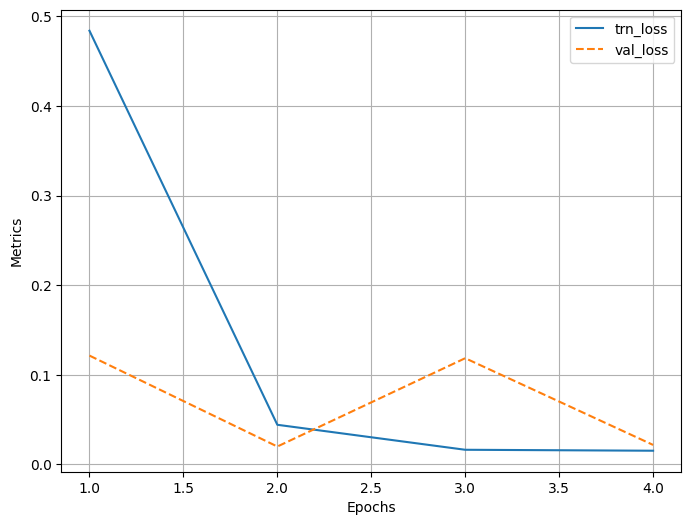

100%|██████████| 105/105 [00:00<00:00, 17483.90it/s]


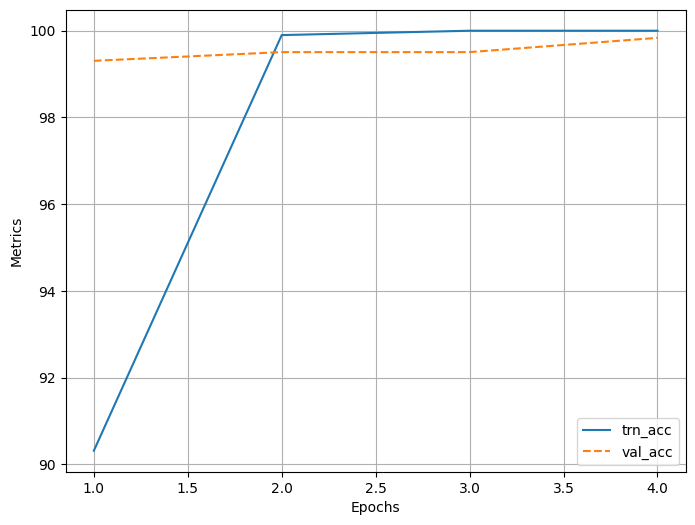

In [ ]:
log.plot_epochs(['trn_loss','val_loss'])
log.plot_epochs(['trn_acc','val_acc'])

Test Accuracy: 99.78%


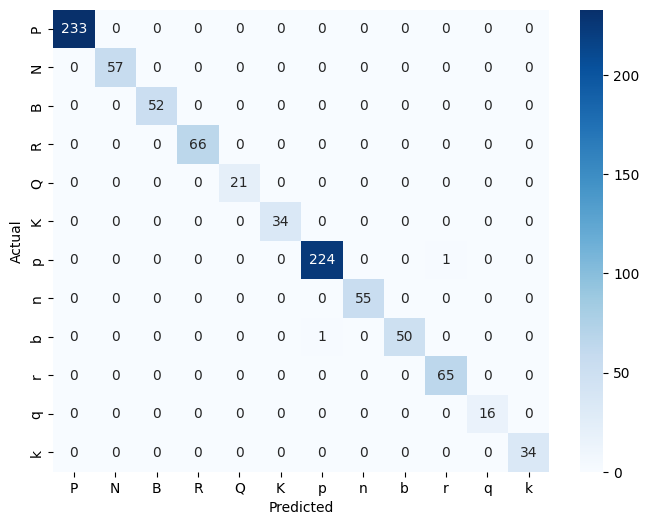

In [ ]:
# Define a mapping between numeric labels and letters
label_mapping = {0: 'P', 1: 'N', 2: 'B', 3: 'R', 4: 'Q', 5: 'K', 6: 'p', 7: 'n', 8: 'b', 9: 'r', 10: 'q', 11: 'k'}

total = 0
right = 0
y_true = []
y_pred = []

with torch.no_grad():                
    N = len(dataLoaderTest)
    for bx, data in enumerate(dataLoaderTest):

        pos, fen_y = data

        pos = pos.to(device)
        fen_y = fen_y.to(device)

        fen_pred = model(pos)

        fen_pred = fen_pred.cpu().detach().numpy().argmax(axis=1)
        fen_y = fen_y.cpu().detach().numpy().argmax(axis=1)

        y_true.extend(fen_y)
        y_pred.extend(fen_pred)

        total += len(fen_y)                
        right += np.sum(fen_pred == fen_y)

accuracy_test = right/total * 100

print(f"Test Accuracy: {accuracy_test:.2f}%")

# Calculate confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Convert numeric labels to letters
label_names = [label_mapping[i] for i in range(len(label_mapping))]

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_names, yticklabels=label_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()
